# Analysis of Tags

In [9]:
import torch
import pandas as pd

# requires the data from Zenodo
data = torch.load("data/final/divers_rich.pt", weights_only=False)

df = pd.DataFrame.from_dict(data["info"], orient="index")
df["dvi"] = df.apply(lambda row: not (row.version in row.filename), axis=1)


## Missing Values

In [10]:
def get_nan_info(df, columns):
    n = len(df)
    for col in columns:
        if col in df.columns:
            if df[col].dtype == float or df[col].dtype == int:
                n_empty = df[col].isna().sum()
            elif df[col].dtype == object:
                n_empty = df[col].apply(len).eq(0).sum()
            print(f"{col}: {n_empty:,} missing ({n_empty / n * 100:.2f}% of total {n})")
        
columns = [
    "tempo",
    "tags_yt_title",
    "tags_yt_description",
    "tags_yt_tags",
]

print("\nNaN info for full dataset")
get_nan_info(df, columns)

print("\nNaN info for DVI dataset")
get_nan_info(df[df.dvi], columns)



NaN info for full dataset
tempo: 7 missing (0.00% of total 1389775)
tags_yt_title: 1,142,445 missing (82.20% of total 1389775)
tags_yt_description: 750,831 missing (54.03% of total 1389775)
tags_yt_tags: 937,699 missing (67.47% of total 1389775)

NaN info for DVI dataset
tempo: 0 missing (0.00% of total 477572)
tags_yt_title: 471,758 missing (98.78% of total 477572)
tags_yt_description: 291,479 missing (61.03% of total 477572)
tags_yt_tags: 371,458 missing (77.78% of total 477572)


## Value Distributions

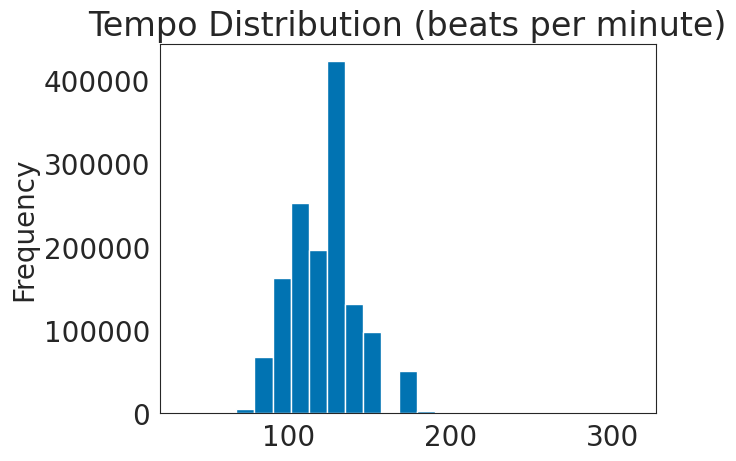

In [11]:
import matplotlib.pyplot as plt

df.tempo.plot(kind="hist", bins=25, title="Tempo Distribution (beats per minute)")
plt.show()


In [12]:
for col in ["tags_yt_title", "tags_yt_description", "tags_yt_tags"]:
    print(f"Analysis of column: {col}")
    ntags = df[col].apply(len)
    n_no_tags = (ntags == 0).sum()
    print(f"{round(n_no_tags/len(ntags)*100,2)}% of items without tags: {n_no_tags:,} out of {len(ntags):,}")
    print(ntags.describe().round(2))
    print("\n")
    

Analysis of column: tags_yt_title
82.2% of items without tags: 1,142,445 out of 1,389,775
count    1389775.00
mean           0.24
std            0.58
min            0.00
25%            0.00
50%            0.00
75%            0.00
max            9.00
Name: tags_yt_title, dtype: float64


Analysis of column: tags_yt_description
54.03% of items without tags: 750,831 out of 1,389,775
count    1389775.00
mean           1.38
std            2.59
min            0.00
25%            0.00
50%            0.00
75%            1.00
max           39.00
Name: tags_yt_description, dtype: float64


Analysis of column: tags_yt_tags
67.47% of items without tags: 937,699 out of 1,389,775
count    1389775.00
mean           0.80
std            1.79
min            0.00
25%            0.00
50%            0.00
75%            1.00
max           40.00
Name: tags_yt_tags, dtype: float64




Saved PDF: figures/matched_tags_title.pdf


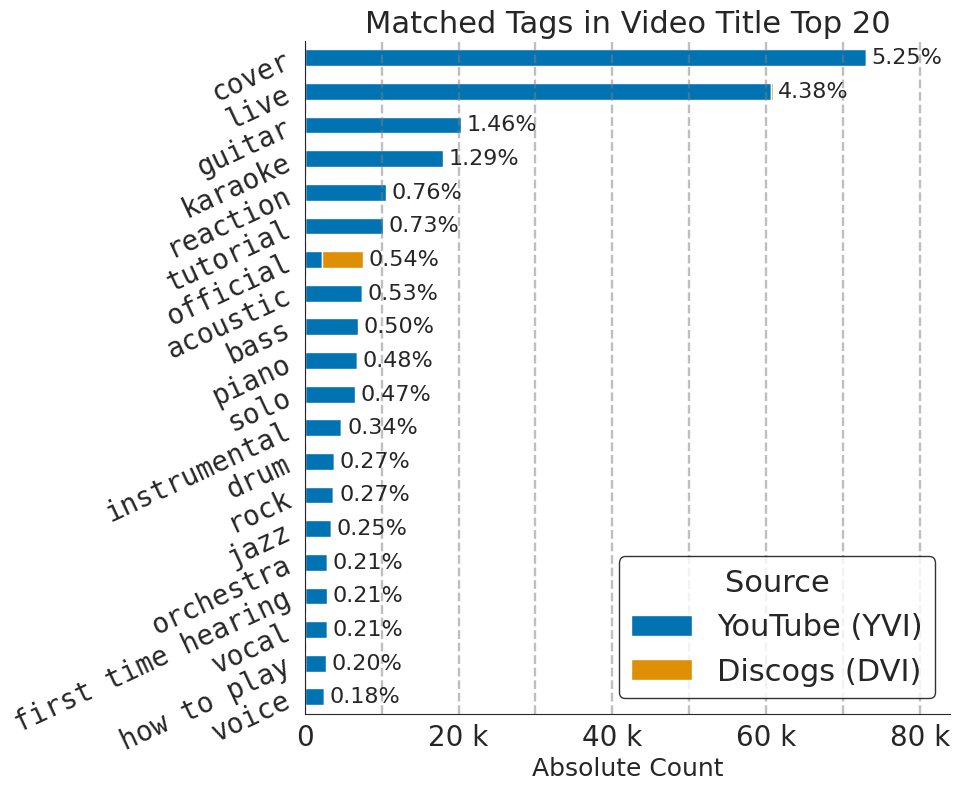

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
import seaborn as sns
import pandas as pd
import numpy as np

df["Source"] = df.apply(lambda row: "Discogs (DVI)" if row.dvi else "YouTube (YVI)", axis=1)

sns.set_palette("colorblind")
sns.set_style(style="white")


def plot_string_counts_barh(df, label_name, top_n=None, out_file=None, hue=None, stacked=True):
    """
    Plot a horizontal bar chart of value counts (absolute and relative) from a Series of lists,
    optionally split (hued) by another column.
    Percentages and vertical lines are always computed on the overall counts.
    """

    # --- helper for y-axis label formatting only ---
    def format_yaxis_label(label):
        label = str(label)
        label = label.replace("firsttimehearing", "first time hearing")
        label = label.replace("howtoplay", "how to play")
        # LaTeX math mode with \texttt{}
        return label #rf"$\texttt{{{label}}}$"
    
    # --- explode lists into rows ---
    exploded = df.explode(label_name)
    exploded[label_name] = exploded[label_name].replace({
        "firsttimehearing": "first time hearing",
        "howtoplay": "how to play"
    })
    # --- compute counts ---
    if hue is None:
        counts = exploded[label_name].value_counts()
        overall_counts = counts
    else:
        counts = exploded.groupby([label_name, hue]).size().unstack(fill_value=0)
        counts = counts[counts.columns[::-1]]  # reverse columns
        if top_n:
            top_labels = counts.sum(axis=1).sort_values(ascending=False).head(top_n).index
            counts = counts.loc[top_labels]
        overall_counts = counts.sum(axis=1)

    if hue is None and top_n:
        counts = counts.head(top_n)
        overall_counts = counts

    # --- compute relative percentages ---
    relative = overall_counts / df.shape[0]

    # --- start plot ---
    plt.rcParams.update({'font.size': 20})
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.grid(True, axis='x', linestyle='--', alpha=0.7)

    if hue is None:
        bars = ax.barh(overall_counts.index, overall_counts.values, color='skyblue')
    else:
        if stacked:
            palette = sns.color_palette("colorblind", n_colors=len(counts.columns))
            counts.plot(
                kind="barh",
                stacked=True,
                ax=ax,
                color=palette,
                legend=True,
            )
        else:
            plot_df = counts.reset_index().melt(id_vars=label_name, var_name=hue, value_name='count')
            sns.barplot(
                data=plot_df,
                y=label_name,
                x='count',
                hue=hue,
                ax=ax,
                palette='colorblind',
                orient='h'
            )

    # --- vertical grid lines ---
    for xtick in ax.get_xticks():
        ax.axvline(x=xtick, color='gray', linestyle='--', linewidth=1.7, alpha=0.5)

    # --- percentage labels ---
    max_val = overall_counts.max()
    for i, (abs_val, rel_val) in enumerate(zip(overall_counts.values, relative.values)):
        ax.text(abs_val + max_val * 0.01, i, f"{rel_val:.2%}", va='center', fontsize=16)

    # --- formatting ---
    ax.set_xlim(0, max_val * 1.15)
    ax.xaxis.set_major_formatter(EngFormatter(unit=''))
    ax.set_xlabel("Absolute Count", fontsize=18)
    ax.invert_yaxis()
    plt.yticks(rotation=25)
    plt.ylabel("")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # --- apply small-caps-like formatting to y-axis tick labels ---
    yticklabels = [format_yaxis_label(t.get_text()) for t in ax.get_yticklabels()]
    ax.set_yticklabels(
        [format_yaxis_label(t.get_text()) for t in ax.get_yticklabels()],
        fontfamily="monospace",  # THIS replicates \texttt{}
        fontsize=20
    )

    # --- legend ---
    if hue is not None:
        ax.legend(
            title=hue,              # legend title
            loc='lower right',      # lower right corner
            frameon=True,           # draw frame around legend
            edgecolor='black',      # frame edge color
            fontsize=22,            # font size of legend entries
            title_fontsize=22       # font size of legend title
        )

    # --- finalize ---
    title_name = label_name.split("_")[-1].title()
    plt.tight_layout()
    if out_file:
        plt.savefig(out_file, format='pdf', bbox_inches='tight')
        print(f"Saved PDF: {out_file}")
    ax.set_title(f"Matched Tags in Video {title_name} Top {top_n}", fontsize=22)
    plt.show()

plot_string_counts_barh(df, "tags_yt_title", top_n=20, out_file="figures/matched_tags_title.pdf", hue="Source", 
                        stacked=True)


Saved PDF: figures/matched_tags_description.pdf


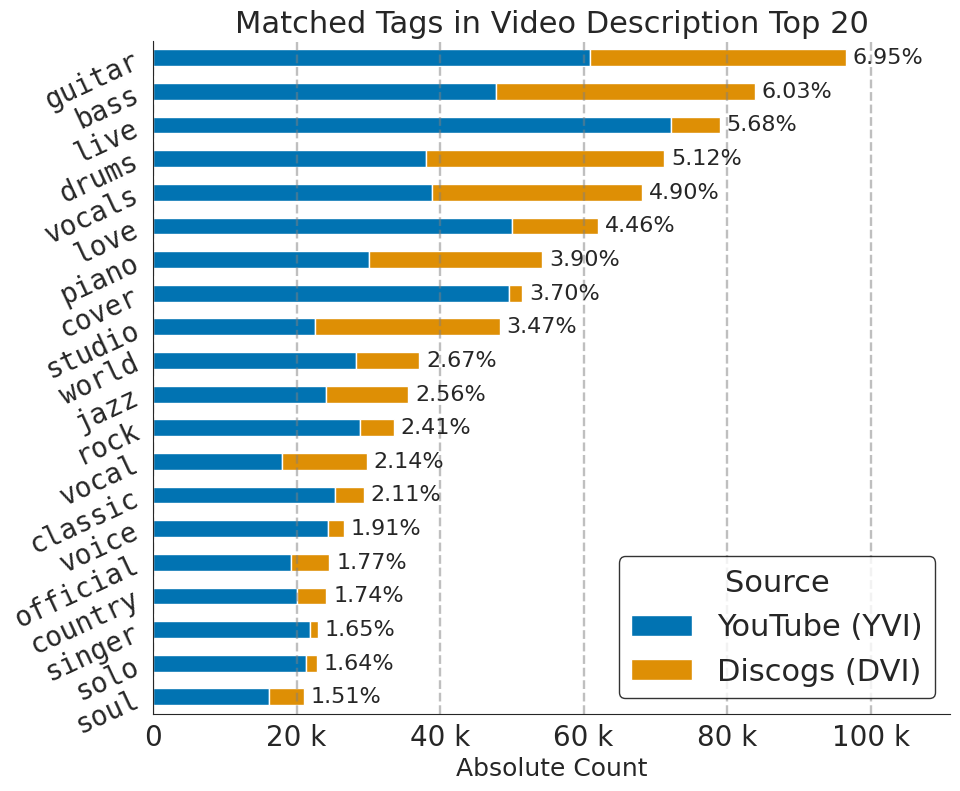

In [20]:
plot_string_counts_barh(df, "tags_yt_description", top_n=20, out_file="figures/matched_tags_description.pdf", hue="Source", 
                        stacked=True)


## Preparation for manual curation

In [7]:
# Explode lists into rows
exploded = df.explode("tags_yt_title")

# Compute tag counts and relative frequencies
n_total = len(df)
df_tag_counts = exploded["tags_yt_title"].value_counts().to_frame()
df_tag_counts["relative"] = df_tag_counts["count"] / n_total
df_tag_counts["relative"] = df_tag_counts["relative"].round(2)
df_tag_counts.sort_values("count", ascending=False).head(60)



,count,relative
tags_yt_title,,
cover,73001,0.05
live,60887,0.04
guitar,20322,0.01
karaoke,17949,0.01
reaction,10599,0.01
tutorial,10110,0.01
official,7528,0.01
acoustic,7383,0.01
bass,6905,0.00


## Annotate
To select a subset for annotation we limit to:
- $k$ most frequently occurring tags in the dataset
- our defined content types
    - backingtrack
    - cover
    - karaoke
    - reaction
    - studio
    - tutorial
    - official
- further selected tags
    - solo
    - instrumental
    - acoustic


In [8]:
import os

# collect tags for which we curate
top_k = 15
top_k_tags = df_tag_counts.head(top_k).index.to_list()
content_type_tags = ["backingtrack", "cover", "karaoke", "reaction", "studio", "tutorial", "official"]
additional_tags = ["instrumental", "acoustic", "solo"]
curate_tags = top_k_tags + content_type_tags + additional_tags

# sample n items per tag for manual annotation
tag_cols = ["tags_yt_title", "tags_yt_description", "tags_yt_tags"]
n = 100
cols = ['id', 'clique', 'version', 'youtube_id', 'artist', 'title', 'dvi', 'yt_title', ]
for tag_col in tag_cols:
    for tag in curate_tags:
        sample = df.loc[df[tag_col].apply(lambda tags: tag in tags), cols + [tag_col, tag_col.replace("tags_", "cues_")]].sample(n=n, random_state=42)
        subdir = f"data/tags/curation/{tag_col}"
        os.makedirs(subdir, exist_ok=True)
        sample.to_csv(f"{subdir}/sample{n}_{tag}.csv", index=False)


KeyboardInterrupt: 